In [1]:
!pip install simplekml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


✅ Librerías cargadas
✅ GEE autenticado e inicializado
📍 CASO: Villegas 2018
📅 Fecha del evento: 2018-10-18
🌩️  Tipo de evento: GRANIZO
📊 Ventana PRE:  2018-10-04 → 2018-10-17
📊 Ventana POST: 2018-10-19 → 2018-11-15
🎯 Umbrales ΔNDVI: Leve=-0.08, Moderado=-0.18, Severo=-0.3
✅ Funciones base definidas

🛰️  Adquiriendo imágenes Sentinel-2...
📍 Período PRE-evento:
    📸 S2_SR_HARMONIZED: 6 imágenes
📍 Período POST-evento:
    📸 S2_HARMONIZED: 10 imágenes

📊 Calculando baseline histórico...
    📸 S2_SR_HARMONIZED: 2 imágenes
    📸 S2_SR_HARMONIZED: 6 imágenes
  ✅ Baseline 2017 calculado
    📸 S2_HARMONIZED: 4 imágenes
    📸 S2_SR_HARMONIZED: 4 imágenes
  ✅ Baseline 2016 calculado
    ❌ Sin imágenes disponibles (2015-10-04 → 2015-10-17). Usando imagen nula.
    ❌ Sin imágenes disponibles (2015-10-19 → 2015-11-15). Usando imagen nula.
  ✅ Baseline 2015 calculado
✅ Baseline histórico listo

💥 Calculando impacto del evento...
✅ Mapa de severidad calculado

📈 Extrayendo estadísticas...

          

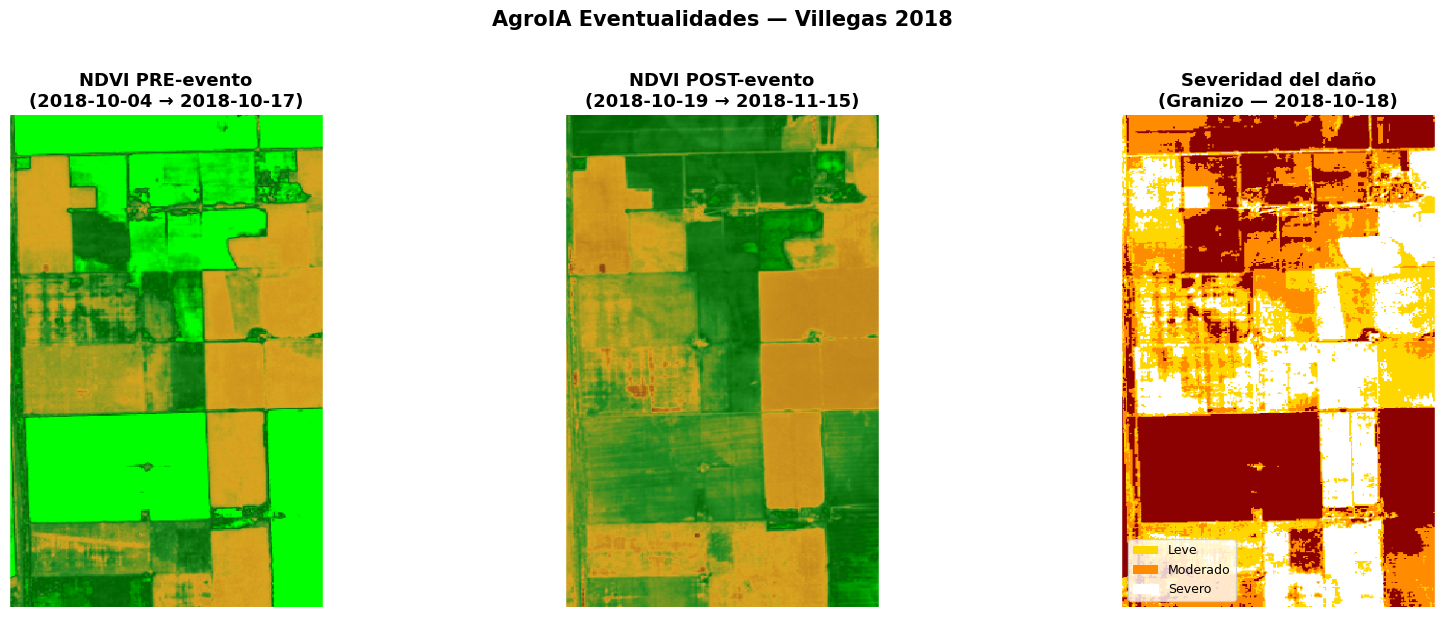

  📌 Gráfico de barras...
    ✅ Guardado: distribucion_dano_villegas_2018.png


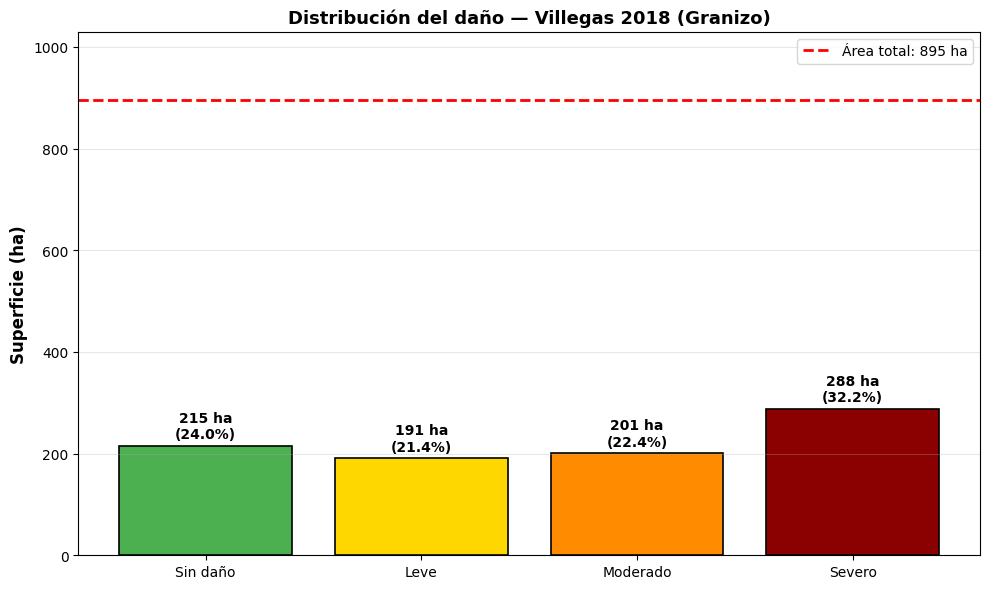

  📌 Gráfico de torta (donut)...
    ✅ Guardado: donut_afectacion_villegas_2018.png


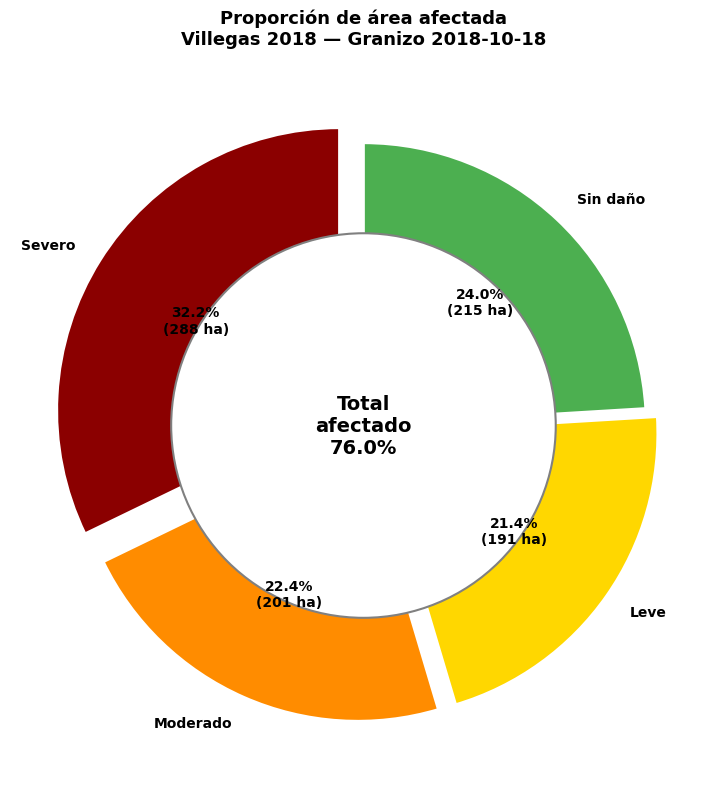


📄 Generando reporte HTML...
  ✅ Guardado: reporte_agroia_villegas_2018.html

📍 Generando puntos de muestreo para peritaje...

📋 HOJA DE RUTA PARA PERITOS:
Categoria    Latitud   Longitud
     Leve -34.821171 -62.987847
     Leve -34.833029 -62.976707
     Leve -34.804642 -62.983175
     Leve -34.825034 -62.990452
     Leve -34.822069 -62.976079
     Leve -34.831501 -62.995931
     Leve -34.807157 -62.996381
     Leve -34.815332 -62.995931
     Leve -34.810122 -62.980660
     Leve -34.796198 -62.982906
 Moderado -34.821171 -62.987847
 Moderado -34.825034 -62.990452
 Moderado -34.822069 -62.976079
 Moderado -34.826740 -62.995752
 Moderado -34.831501 -62.995931
 Moderado -34.833029 -62.976707
 Moderado -34.804642 -62.983175
 Moderado -34.829166 -62.975629
 Moderado -34.805540 -62.988206
 Moderado -34.830154 -62.995213
   Severo -34.833029 -62.976707
   Severo -34.804642 -62.983175
   Severo -34.831501 -62.995931
   Severo -34.829166 -62.975629
   Severo -34.805540 -62.988206
   Severo -3

Map(center=[-34.81468558608482, -62.98743830995251], controls=(WidgetControl(options=['position', 'transparent…

In [2]:
# -*- coding: utf-8 -*-
"""
================================================================================
  AgroIA EVENTUALIDADES — Evaluación de Daños por Eventos Climáticos
  Versión 2.0 — Pipeline unificado para Colab
================================================================================
  Tipos de evento soportados: granizo, helada, viento, sequia, inundacion
  Fuente satelital: Sentinel-2 SR (con fallback a TOA automático)
  Baseline histórico: 3 años misma ventana fenológica
  Salidas: mapa interactivo, gráficos PNG, reporte HTML, CSV, KML de peritaje
================================================================================
"""

# ============================================================
# CELDA 1 — Instalación y configuración inicial
# ============================================================
# !pip install geemap geopandas simplekml -q  # Descomentar en Colab

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from IPython.display import display, HTML
import folium
from folium import plugins
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas")

# ============================================================
# CELDA 2 — Autenticación GEE
# ============================================================
try:
    ee.Initialize(project='applied-oxygen-459415-e2')
    print("✅ GEE inicializado")
except Exception:
    ee.Authenticate()
    ee.Initialize(project='applied-oxygen-459415-e2')
    print("✅ GEE autenticado e inicializado")

# ============================================================
# CELDA 3 — Configuración del caso
# ============================================================

# ── Geometría del lote ────────────────────────────────────────
lote = ee.Geometry.Polygon([[
    [-62.9992603277508891, -34.8333361077352492],
    [-62.9756162921428100, -34.8333361077352492],
    [-62.9756162921428100, -34.7960367353062026],
    [-62.9992603277508891, -34.7960367353062026],
    [-62.9992603277508891, -34.8333361077352492]
]])

# ── Parámetros del evento ─────────────────────────────────────
NOMBRE_CASO   = "Villegas 2018"
FECHA_EVENTO  = "2018-10-18"

# Tipo de evento: "granizo" | "helada" | "viento" | "sequia" | "inundacion"
TIPO_EVENTO   = "granizo"

# Ventanas temporales (ajustar según disponibilidad de imágenes)
PRE_INI  = "2018-10-04"
PRE_FIN  = "2018-10-17"
POST_INI = "2018-10-19"
POST_FIN = "2018-11-15"   # extendida para cubrir nubes

# Máxima nubosidad permitida (%)
MAX_NUBES = 40

# ── Umbrales por tipo de evento ───────────────────────────────
# Los valores representan ΔNDVI ajustado (negativo = pérdida)
UMBRALES_POR_EVENTO = {
    "granizo": {
        "leve":     -0.08,
        "moderado": -0.18,
        "severo":   -0.30,
        "total":    -0.45,
        "descripcion": "daño mecánico por impacto de granizo",
        "recomendacion_severo": "inspección inmediata + evaluación de resiembra",
    },
    "helada": {
        "leve":     -0.06,
        "moderado": -0.14,
        "severo":   -0.25,
        "total":    -0.40,
        "descripcion": "quemadura foliar por temperaturas bajo cero",
        "recomendacion_severo": "evaluar recuperación en 10-15 días antes de decidir resiembra",
    },
    "viento": {
        "leve":     -0.07,
        "moderado": -0.15,
        "severo":   -0.27,
        "total":    -0.42,
        "descripcion": "acame y defoliación por vientos fuertes",
        "recomendacion_severo": "inspección de acame + evaluación de encamado irreversible",
    },
    "sequia": {
        "leve":     -0.10,
        "moderado": -0.20,
        "severo":   -0.35,
        "total":    -0.50,
        "descripcion": "estrés hídrico acumulado",
        "recomendacion_severo": "monitorear cierre de ciclo + proyectar pérdida de rinde",
    },
    "inundacion": {
        "leve":     -0.09,
        "moderado": -0.18,
        "severo":   -0.30,
        "total":    -0.48,
        "descripcion": "anegamiento y asfixia radicular",
        "recomendacion_severo": "relevamiento de lámina de agua + días de inundación acumulados",
    },
}

UMBRALES = UMBRALES_POR_EVENTO[TIPO_EVENTO]

print("=" * 60)
print(f"📍 CASO: {NOMBRE_CASO}")
print(f"📅 Fecha del evento: {FECHA_EVENTO}")
print(f"🌩️  Tipo de evento: {TIPO_EVENTO.upper()}")
print(f"📊 Ventana PRE:  {PRE_INI} → {PRE_FIN}")
print(f"📊 Ventana POST: {POST_INI} → {POST_FIN}")
print(f"🎯 Umbrales ΔNDVI: Leve={UMBRALES['leve']}, "
      f"Moderado={UMBRALES['moderado']}, Severo={UMBRALES['severo']}")
print("=" * 60)

# ============================================================
# CELDA 4 — Funciones base (TODAS definidas aquí antes de usarse)
# ============================================================

def add_ndvi(image):
    """Calcula NDVI y lo añade como banda. Compatible con SR y TOA."""
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)


def get_median_ndvi(start_date, end_date, geometry, max_cloud=MAX_NUBES):
    """
    Obtiene la mediana de NDVI para una ventana temporal.
    Intenta SR primero; si no hay imágenes disponibles, cae a TOA.
    Retorna (imagen_ee, nombre_coleccion, n_imagenes).
    """
    for collection_name in ['COPERNICUS/S2_SR_HARMONIZED', 'COPERNICUS/S2_HARMONIZED']:
        col = (ee.ImageCollection(collection_name)
               .filterBounds(geometry)
               .filterDate(start_date, end_date)
               .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', max_cloud))
               .map(add_ndvi)
               .select('NDVI'))
        n = col.size().getInfo()
        if n > 0:
            print(f"    📸 {collection_name.split('/')[-1]}: {n} imágenes")
            return col.median().clip(geometry), collection_name, n

    print(f"    ❌ Sin imágenes disponibles ({start_date} → {end_date}). Usando imagen nula.")
    return ee.Image(0).rename('NDVI').clip(geometry), "SIN_DATOS", 0


def calculate_area(mask_image, geometry, scale=10):
    """
    Calcula el área en hectáreas de los píxeles verdaderos en mask_image.
    """
    area_img = mask_image.multiply(ee.Image.pixelArea())
    result = area_img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=geometry,
        scale=scale,
        bestEffort=True
    ).getInfo()
    # La banda puede llamarse 'NDVI', 'constant', 'severidad', etc.
    val = list(result.values())[0] if result else 0
    return (val or 0) / 10000  # m² → ha


def get_ndvi_mean(image, geometry, band='NDVI', scale=10):
    """Extrae el valor medio de NDVI (o cualquier banda) sobre la geometría."""
    result = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=scale,
        bestEffort=True
    ).getInfo()
    return round(result.get(band, 0) or 0, 4)


print("✅ Funciones base definidas")

# ============================================================
# CELDA 5 — Adquisición de imágenes PRE y POST
# ============================================================
print("\n🛰️  Adquiriendo imágenes Sentinel-2...")

print("📍 Período PRE-evento:")
ndvi_pre, col_pre, n_pre = get_median_ndvi(PRE_INI, PRE_FIN, lote)

print("📍 Período POST-evento:")
ndvi_post, col_post, n_post = get_median_ndvi(POST_INI, POST_FIN, lote)

# ============================================================
# CELDA 6 — Baseline histórico (3 años, misma ventana fenológica)
# ============================================================
print("\n📊 Calculando baseline histórico...")

# Año del evento para referenciar los años anteriores
anio_evento = int(FECHA_EVENTO[:4])

deltas_baseline = []
for offset in [1, 2, 3]:
    anio = anio_evento - offset
    pre_b,  _, _ = get_median_ndvi(f'{anio}{PRE_INI[4:]}',  f'{anio}{PRE_FIN[4:]}',  lote)
    post_b, _, _ = get_median_ndvi(f'{anio}{POST_INI[4:]}', f'{anio}{POST_FIN[4:]}', lote)
    deltas_baseline.append(post_b.subtract(pre_b))
    print(f"  ✅ Baseline {anio} calculado")

# Media de los 3 deltas históricos
baseline_3y = (deltas_baseline[0]
               .add(deltas_baseline[1])
               .add(deltas_baseline[2])
               .divide(3)
               .rename('baseline_3y'))

print("✅ Baseline histórico listo")

# ============================================================
# CELDA 7 — Cálculo del daño y clasificación de severidad
# ============================================================
print("\n💥 Calculando impacto del evento...")

# ΔNDVI observado y ajustado por baseline fenológico
delta_obs = ndvi_post.subtract(ndvi_pre).rename('delta_observado')
delta_adj = delta_obs.subtract(baseline_3y).rename('delta_ajustado')

# Mapa de severidad: 1=Leve, 2=Moderado, 3=Severo
# Se construye sumando máscaras binarias ponderadas para evitar solapamiento
mask_leve     = delta_adj.lt(UMBRALES['leve']).And(delta_adj.gte(UMBRALES['moderado']))
mask_moderado = delta_adj.lt(UMBRALES['moderado']).And(delta_adj.gte(UMBRALES['severo']))
mask_severo   = delta_adj.lt(UMBRALES['severo'])

severidad = (mask_leve.multiply(1)
             .add(mask_moderado.multiply(2))
             .add(mask_severo.multiply(3))
             .rename('severidad'))

print("✅ Mapa de severidad calculado")

# ============================================================
# CELDA 8 — Estadísticas
# ============================================================
print("\n📈 Extrayendo estadísticas...")

area_total        = lote.area().divide(10000).getInfo()
ndvi_pre_val      = get_ndvi_mean(ndvi_pre,  lote)
ndvi_post_val     = get_ndvi_mean(ndvi_post, lote)
delta_obs_val     = round(ndvi_post_val - ndvi_pre_val, 4)
delta_adj_val     = get_ndvi_mean(delta_adj, lote, band='delta_ajustado')
baseline_val      = get_ndvi_mean(baseline_3y, lote, band='baseline_3y')

area_leve          = calculate_area(mask_leve,     lote)
area_moderada      = calculate_area(mask_moderado,  lote)
area_severa        = calculate_area(mask_severo,    lote)
area_afectada      = area_leve + area_moderada + area_severa
pct_afectado       = area_afectada / area_total * 100

# ── Nivel de confianza ─────────────────────────────────────────
if n_post >= 3:
    confianza = "ALTA";   emoji_conf = "🟢"
elif n_post >= 1:
    confianza = "MEDIA";  emoji_conf = "🟠"
else:
    confianza = "BAJA";   emoji_conf = "🔴"

# ── Interpretación automática según tipo de evento ────────────
if n_post == 0:
    interpretacion = ("❌ ALERTA: Sin imágenes post-evento. "
                      "Ampliar ventana o usar Sentinel-1 (radar).")
elif delta_adj_val <= UMBRALES['severo']:
    interpretacion = (f"⚠️  ANOMALÍA CRÍTICA: caída de vigor de {delta_adj_val:+.3f}. "
                      f"Patrón consistente con {UMBRALES['descripcion']}. "
                      f"Área severa: {area_severa:.1f} ha ({area_severa/area_total*100:.1f}%). "
                      f"→ {UMBRALES['recomendacion_severo']}")
elif delta_adj_val <= UMBRALES['moderado']:
    interpretacion = (f"🟠 IMPACTO MODERADO: afectación sistémica del lote "
                      f"(ΔNDVI ajustado: {delta_adj_val:+.3f}).")
else:
    interpretacion = (f"🟢 SIN IMPACTO MAYOR: valores dentro del rango histórico "
                      f"(ΔNDVI ajustado: {delta_adj_val:+.3f}).")

# ── Reporte en consola ─────────────────────────────────────────
sep = "─" * 70
print(f"\n{'=' * 70}")
print(f"            🌾 INFORME AgroIA EVENTUALIDADES — {NOMBRE_CASO.upper()} 🌾")
print(f"{'=' * 70}")
print(f"\n📍 Caso:           {NOMBRE_CASO}")
print(f"🌩️  Evento:         {TIPO_EVENTO.capitalize()} — {FECHA_EVENTO}")
print(f"🛰️  Fuente:         Sentinel-2 ({col_pre.split('/')[-1]})")
print(f"\n{sep}")
print("📊 MÉTRICAS DE VEGETACIÓN")
print(f"{sep}")
print(f"  NDVI pre-evento:          {ndvi_pre_val:.4f}")
print(f"  NDVI post-evento:         {ndvi_post_val:.4f}")
print(f"  ΔNDVI observado:          {delta_obs_val:+.4f}")
print(f"  Baseline histórico (3a):  {baseline_val:+.4f}")
print(f"  ΔNDVI ajustado:           {delta_adj_val:+.4f}  ← indicador de daño real")
print(f"\n{sep}")
print(f"💥 SUPERFICIE AFECTADA ({TIPO_EVENTO.upper()})")
print(f"{sep}")
print(f"  Área total del lote:          {area_total:.1f} ha")
print(f"  🟡 Daño LEVE   (>{abs(UMBRALES['leve']):.0%} ΔNDVI):  "
      f"{area_leve:.1f} ha ({area_leve/area_total*100:.1f}%)")
print(f"  🟠 Daño MODERADO (>{abs(UMBRALES['moderado']):.0%}):  "
      f"{area_moderada:.1f} ha ({area_moderada/area_total*100:.1f}%)")
print(f"  🔴 Daño SEVERO   (>{abs(UMBRALES['severo']):.0%}):  "
      f"{area_severa:.1f} ha ({area_severa/area_total*100:.1f}%)")
print(f"{sep}")
print(f"  TOTAL AFECTADO:               {area_afectada:.1f} ha ({pct_afectado:.1f}%)")
print(f"\n{sep}")
print(f"🔎 INTERPRETACIÓN AGRONÓMICA")
print(f"{sep}")
print(f"  {interpretacion}")
print(f"\n  Confianza del análisis: {emoji_conf} {confianza} "
      f"({n_pre} img PRE / {n_post} img POST, baseline 3 años)")
print(f"{'=' * 70}")

# ============================================================
# CELDA 9 — Mapa interactivo (geemap)
# ============================================================
print("\n🗺️  Generando mapa interactivo...")

mapa = geemap.Map()
mapa.centerObject(lote, zoom=13)

vis_ndvi = {
    'min': 0, 'max': 0.8,
    'palette': ['#8B4513', '#DAA520', '#228B22', '#006400', '#00FF00']
}
vis_delta = {
    'min': -0.5, 'max': 0.1,
    'palette': ['#8B0000', '#DC143C', '#FF6347', '#FFD700', '#F0FFF0']
}
vis_sev = {
    'min': 0, 'max': 3,
    'palette': ['#FFFFFF', '#FFD700', '#FF8C00', '#8B0000']
}

mapa.addLayer(ndvi_pre,  vis_ndvi,  '🌿 NDVI PRE-evento')
mapa.addLayer(ndvi_post, vis_ndvi,  '🌾 NDVI POST-evento')
mapa.addLayer(delta_obs, vis_delta, '📉 ΔNDVI Observado')
mapa.addLayer(delta_adj, vis_delta, '📊 ΔNDVI Ajustado (anomalía)')
mapa.addLayer(severidad.selfMask(), vis_sev,
              '💥 Severidad del daño (🔴Severo 🟠Moderado 🟡Leve)')
mapa.addLayer(
    ee.Image().paint(lote, 0, 3),
    {'palette': ['#000000']},
    '📐 Límite del lote'
)

mapa.add_legend(
    title=f"Daño por {TIPO_EVENTO}",
    legend_dict={
        '🟡 Leve':    '#FFD700',
        '🟠 Moderado': '#FF8C00',
        '🔴 Severo':   '#8B0000',
        '⚪ Sin daño': '#FFFFFF',
    }
)
mapa.addLayerControl()

# ============================================================
# CELDA 10 — Exportar capas a Google Drive
# ============================================================
print("\n💾 Exportando capas a Google Drive...")

slug = NOMBRE_CASO.lower().replace(" ", "_")
carpeta_drive = f"AgroIA_Eventualidades_{slug}"

for img, nombre, vis in [
    (ndvi_pre,  f'ndvi_pre_{slug}',       vis_ndvi),
    (ndvi_post, f'ndvi_post_{slug}',      vis_ndvi),
    (delta_obs, f'delta_obs_{slug}',      vis_delta),
    (delta_adj, f'delta_ajustado_{slug}', vis_delta),
    (severidad, f'severidad_{slug}',      vis_sev),
]:
    task = ee.batch.Export.image.toDrive(
        image=img.visualize(**vis),
        description=nombre,
        folder=carpeta_drive,
        fileNamePrefix=nombre,
        region=lote,
        scale=10,
        crs='EPSG:4326',
        maxPixels=1e9
    )
    task.start()
    print(f"  ✅ Exportando: {nombre}")

# ============================================================
# CELDA 11 — Visualizaciones matplotlib
# ============================================================
print("\n🎨 Generando visualizaciones...")

# ── 11.1 Comparativa NDVI pre/post ────────────────────────────
print("  📌 Comparativa NDVI pre/post...")

# Descarga de thumbnails para matplotlib
def get_thumbnail_array(img, vis_params, region, dims=512):
    url = img.visualize(**vis_params).getThumbURL({
        'region': region,
        'dimensions': dims,
        'format': 'png'
    })
    import requests
    from PIL import Image
    import io
    resp = requests.get(url, timeout=60)
    return np.array(Image.open(io.BytesIO(resp.content)))

try:
    arr_pre  = get_thumbnail_array(ndvi_pre,  vis_ndvi,  lote)
    arr_post = get_thumbnail_array(ndvi_post, vis_ndvi,  lote)
    arr_sev  = get_thumbnail_array(severidad, vis_sev,   lote)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(arr_pre)
    axes[0].set_title(f'NDVI PRE-evento\n({PRE_INI} → {PRE_FIN})',
                      fontsize=13, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(arr_post)
    axes[1].set_title(f'NDVI POST-evento\n({POST_INI} → {POST_FIN})',
                      fontsize=13, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(arr_sev)
    axes[2].set_title(f'Severidad del daño\n({TIPO_EVENTO.capitalize()} — {FECHA_EVENTO})',
                      fontsize=13, fontweight='bold')
    legend_elements = [
        Patch(facecolor='#FFD700', label='Leve'),
        Patch(facecolor='#FF8C00', label='Moderado'),
        Patch(facecolor='#8B0000', color='white', label='Severo'),
    ]
    axes[2].legend(handles=legend_elements, loc='lower left', fontsize=9)
    axes[2].axis('off')

    plt.suptitle(f'AgroIA Eventualidades — {NOMBRE_CASO}',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    nombre_comparativa = f'comparativa_ndvi_{slug}.png'
    plt.savefig(nombre_comparativa, dpi=200, bbox_inches='tight')
    print(f"    ✅ Guardado: {nombre_comparativa}")
    plt.show()

except Exception as e:
    print(f"    ⚠️  No se pudieron generar thumbnails: {e}")
    print("    → Continuando con el resto del pipeline.")

# ── 11.2 Gráfico de barras ─────────────────────────────────────
print("  📌 Gráfico de barras...")

fig2, ax = plt.subplots(figsize=(10, 6))
categorias = ['Sin daño', 'Leve', 'Moderado', 'Severo']
areas_bar  = [area_total - area_afectada, area_leve, area_moderada, area_severa]
colores_b  = ['#4CAF50', '#FFD700', '#FF8C00', '#8B0000']

bars = ax.bar(categorias, areas_bar, color=colores_b, edgecolor='black', linewidth=1.2)
for bar, area in zip(bars, areas_bar):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + area_total * 0.01,
            f'{area:.0f} ha\n({area/area_total*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Superficie (ha)', fontsize=12, fontweight='bold')
ax.set_title(f'Distribución del daño — {NOMBRE_CASO} ({TIPO_EVENTO.capitalize()})',
             fontsize=13, fontweight='bold')
ax.axhline(y=area_total, color='red', linestyle='--', lw=2,
           label=f'Área total: {area_total:.0f} ha')
ax.set_ylim(0, area_total * 1.15)
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
nombre_barras = f'distribucion_dano_{slug}.png'
plt.savefig(nombre_barras, dpi=200, bbox_inches='tight')
print(f"    ✅ Guardado: {nombre_barras}")
plt.show()

# ── 11.3 Donut de afectación ───────────────────────────────────
print("  📌 Gráfico de torta (donut)...")

fig3, ax = plt.subplots(figsize=(9, 8))
labels_pie  = ['Severo', 'Moderado', 'Leve', 'Sin daño']
sizes_pie   = [area_severa, area_moderada, area_leve, area_total - area_afectada]
colors_pie  = ['#8B0000', '#FF8C00', '#FFD700', '#4CAF50']
explode_pie = (0.10, 0.05, 0.05, 0)

wedges, texts, autotexts = ax.pie(
    sizes_pie, explode=explode_pie, labels=labels_pie, colors=colors_pie,
    autopct=lambda pct: f'{pct:.1f}%\n({pct * area_total / 100:.0f} ha)',
    startangle=90,
    textprops={'fontsize': 10, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
centre_circle = plt.Circle((0, 0), 0.68, fc='white', linewidth=1.5, edgecolor='gray')
fig3.gca().add_artist(centre_circle)
ax.text(0, 0, f'Total\nafectado\n{pct_afectado:.1f}%',
        ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_title(f'Proporción de área afectada\n{NOMBRE_CASO} — {TIPO_EVENTO.capitalize()} {FECHA_EVENTO}',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
nombre_donut = f'donut_afectacion_{slug}.png'
plt.savefig(nombre_donut, dpi=200, bbox_inches='tight')
print(f"    ✅ Guardado: {nombre_donut}")
plt.show()

# ============================================================
# CELDA 12 — Reporte HTML ejecutivo
# ============================================================
print("\n📄 Generando reporte HTML...")

# Paleta de colores para el badge del tipo de evento
badge_color = {
    "granizo":    "#4A90D9",
    "helada":     "#8E44AD",
    "viento":     "#27AE60",
    "sequia":     "#E67E22",
    "inundacion": "#2980B9",
}.get(TIPO_EVENTO, "#555")

html_content = f"""<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <title>AgroIA Eventualidades — {NOMBRE_CASO}</title>
  <style>
    * {{ box-sizing: border-box; margin: 0; padding: 0; }}
    body {{
      font-family: 'Segoe UI', Arial, sans-serif;
      background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
      padding: 24px;
    }}
    .container {{
      max-width: 1100px; margin: 0 auto;
      background: white; border-radius: 16px; padding: 36px;
      box-shadow: 0 24px 48px rgba(0,0,0,0.3);
    }}
    .header {{ text-align: center; margin-bottom: 32px; }}
    .header h1 {{ font-size: 24px; color: #1a1a2e; margin-bottom: 8px; }}
    .badge {{
      display: inline-block; padding: 6px 18px; border-radius: 20px;
      background: {badge_color}; color: white; font-weight: bold;
      font-size: 13px; letter-spacing: 1px; text-transform: uppercase;
      margin-bottom: 12px;
    }}
    .meta {{ color: #666; font-size: 13px; line-height: 1.8; }}
    .stats-grid {{
      display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
      gap: 16px; margin: 28px 0;
    }}
    .stat-card {{
      background: linear-gradient(135deg, #f8f9fa, #e9ecef);
      border-radius: 12px; padding: 20px; text-align: center;
      border-top: 4px solid {badge_color};
    }}
    .stat-label {{ font-size: 12px; color: #666; margin-bottom: 6px; }}
    .stat-number {{ font-size: 30px; font-weight: bold; color: #1a1a2e; }}
    .stat-sub {{ font-size: 12px; color: #888; margin-top: 4px; }}
    h2 {{ font-size: 17px; color: #1a1a2e; border-left: 4px solid {badge_color};
          padding-left: 12px; margin: 28px 0 14px; }}
    .severity-bar {{
      display: flex; border-radius: 8px; overflow: hidden;
      height: 36px; margin: 16px 0; font-size: 13px; font-weight: bold;
    }}
    .sev-severo  {{ background: #8B0000; color: white; display: flex;
                    align-items: center; justify-content: center; }}
    .sev-moderado{{ background: #FF8C00; color: white; display: flex;
                    align-items: center; justify-content: center; }}
    .sev-leve    {{ background: #FFD700; color: #333; display: flex;
                    align-items: center; justify-content: center; }}
    .sev-ok      {{ background: #4CAF50; color: white; display: flex;
                    align-items: center; justify-content: center; }}
    .interp-box {{
      background: #f8f9fa; border-left: 5px solid {badge_color};
      border-radius: 8px; padding: 16px; font-size: 14px; line-height: 1.7;
      margin: 16px 0;
    }}
    table {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
    th {{ background: #1a1a2e; color: white; padding: 10px 14px; text-align: left; }}
    td {{ padding: 9px 14px; border-bottom: 1px solid #eee; }}
    tr:nth-child(even) {{ background: #f8f9fa; }}
    ul {{ padding-left: 20px; font-size: 14px; line-height: 2; }}
    .footer {{
      text-align: center; margin-top: 32px; padding-top: 20px;
      border-top: 1px solid #ddd; color: #aaa; font-size: 12px;
    }}
    .confidence {{
      display: inline-block; padding: 4px 12px; border-radius: 12px;
      font-size: 12px; font-weight: bold;
      background: {"#d4edda" if confianza == "ALTA" else "#fff3cd" if confianza == "MEDIA" else "#f8d7da"};
      color: {"#155724" if confianza == "ALTA" else "#856404" if confianza == "MEDIA" else "#721c24"};
    }}
  </style>
</head>
<body>
<div class="container">

  <div class="header">
    <div class="badge">🌩️ {TIPO_EVENTO}</div>
    <h1>🌾 INFORME AgroIA EVENTUALIDADES</h1>
    <div class="meta">
      <strong>Caso:</strong> {NOMBRE_CASO} &nbsp;|&nbsp;
      <strong>Fecha del evento:</strong> {FECHA_EVENTO} &nbsp;|&nbsp;
      <strong>Fuente:</strong> Sentinel-2 L2A (10 m) &nbsp;|&nbsp;
      <strong>Método:</strong> ΔNDVI con baseline histórico 3 años
    </div>
  </div>

  <div class="stats-grid">
    <div class="stat-card">
      <div class="stat-label">📐 Área total</div>
      <div class="stat-number">{area_total:.0f}</div>
      <div class="stat-sub">hectáreas</div>
    </div>
    <div class="stat-card">
      <div class="stat-label">💥 Área afectada</div>
      <div class="stat-number">{area_afectada:.0f}</div>
      <div class="stat-sub">{pct_afectado:.1f}% del lote</div>
    </div>
    <div class="stat-card">
      <div class="stat-label">🌿 NDVI Pre</div>
      <div class="stat-number">{ndvi_pre_val:.3f}</div>
      <div class="stat-sub">{PRE_INI} → {PRE_FIN}</div>
    </div>
    <div class="stat-card">
      <div class="stat-label">🌾 NDVI Post</div>
      <div class="stat-number">{ndvi_post_val:.3f}</div>
      <div class="stat-sub">{POST_INI} → {POST_FIN}</div>
    </div>
    <div class="stat-card">
      <div class="stat-label">📉 ΔNDVI ajustado</div>
      <div class="stat-number">{delta_adj_val:+.3f}</div>
      <div class="stat-sub">anomalía sobre baseline</div>
    </div>
    <div class="stat-card">
      <div class="stat-label">🔎 Confianza</div>
      <div class="stat-number" style="font-size:20px">{emoji_conf} {confianza}</div>
      <div class="stat-sub">{n_pre} img PRE / {n_post} img POST</div>
    </div>
  </div>

  <h2>📊 Distribución del daño</h2>
  <div class="severity-bar">
    <div class="sev-severo"  style="width:{area_severa/area_total*100:.1f}%">
      🔴 {area_severa:.0f} ha ({area_severa/area_total*100:.1f}%)
    </div>
    <div class="sev-moderado" style="width:{area_moderada/area_total*100:.1f}%">
      🟠 {area_moderada:.0f} ha ({area_moderada/area_total*100:.1f}%)
    </div>
    <div class="sev-leve"    style="width:{area_leve/area_total*100:.1f}%">
      🟡 {area_leve:.0f} ha ({area_leve/area_total*100:.1f}%)
    </div>
    <div class="sev-ok"      style="flex:1">
      ✅ {area_total-area_afectada:.0f} ha ({(area_total-area_afectada)/area_total*100:.1f}%)
    </div>
  </div>

  <h2>📋 Tabla de métricas</h2>
  <table>
    <tr><th>Métrica</th><th>Valor</th></tr>
    <tr><td>Área total</td><td>{area_total:.1f} ha</td></tr>
    <tr><td>NDVI pre-evento</td><td>{ndvi_pre_val:.4f}</td></tr>
    <tr><td>NDVI post-evento</td><td>{ndvi_post_val:.4f}</td></tr>
    <tr><td>ΔNDVI observado</td><td>{delta_obs_val:+.4f}</td></tr>
    <tr><td>Baseline histórico (3 años)</td><td>{baseline_val:+.4f}</td></tr>
    <tr><td>ΔNDVI ajustado (anomalía)</td><td><strong>{delta_adj_val:+.4f}</strong></td></tr>
    <tr><td>Área leve ({abs(UMBRALES['leve']):.0%}–{abs(UMBRALES['moderado']):.0%} ΔNDVI)</td><td>{area_leve:.1f} ha ({area_leve/area_total*100:.1f}%)</td></tr>
    <tr><td>Área moderada ({abs(UMBRALES['moderado']):.0%}–{abs(UMBRALES['severo']):.0%} ΔNDVI)</td><td>{area_moderada:.1f} ha ({area_moderada/area_total*100:.1f}%)</td></tr>
    <tr><td>Área severa (>{abs(UMBRALES['severo']):.0%} ΔNDVI)</td><td>{area_severa:.1f} ha ({area_severa/area_total*100:.1f}%)</td></tr>
    <tr><td>Total afectado</td><td><strong>{area_afectada:.1f} ha ({pct_afectado:.1f}%)</strong></td></tr>
  </table>

  <h2>🎯 Interpretación agronómica</h2>
  <div class="interp-box">{interpretacion}</div>

  <h2>✅ Recomendaciones</h2>
  <ul>
    <li>Priorizar inspección en campo del área severa ({area_severa:.0f} ha)</li>
    <li>{UMBRALES['recomendacion_severo']}</li>
    <li>Documentar con fotografías georreferenciadas en los puntos de muestreo exportados</li>
    <li>Monitorear evolución post-evento con nueva imagen en 15 días</li>
    <li>Verificar consistencia con registros meteorológicos del evento ({FECHA_EVENTO})</li>
  </ul>

  <h2>🔬 Trazabilidad del análisis</h2>
  <table>
    <tr><th>Parámetro</th><th>Detalle</th></tr>
    <tr><td>Sensor</td><td>Sentinel-2 MSI — Copernicus / ESA</td></tr>
    <tr><td>Colección PRE</td><td>{col_pre}</td></tr>
    <tr><td>Colección POST</td><td>{col_post}</td></tr>
    <tr><td>Resolución espacial</td><td>10 m/píxel</td></tr>
    <tr><td>Índice utilizado</td><td>NDVI = (B8 − B4) / (B8 + B4)</td></tr>
    <tr><td>Baseline fenológico</td><td>{anio_evento-3} – {anio_evento-1} (misma ventana)</td></tr>
    <tr><td>Confianza del análisis</td><td><span class="confidence">{confianza}</span> — {n_pre} img PRE / {n_post} img POST</td></tr>
    <tr><td>Procesamiento</td><td>Google Earth Engine — AgroIA v2.0</td></tr>
    <tr><td>Fecha de generación</td><td>{datetime.now().strftime('%Y-%m-%d %H:%M')}</td></tr>
  </table>

  <div class="footer">
    Reporte generado por <strong>AgroIA Eventualidades v2.0</strong> —
    Pipeline satelital automático sobre Copernicus/Sentinel-2<br>
    Los valores son estimaciones satelitales. Se recomienda validación en campo para siniestros formales.
  </div>

</div>
</body>
</html>"""

nombre_html = f'reporte_agroia_{slug}.html'
with open(nombre_html, 'w', encoding='utf-8') as f:
    f.write(html_content)
print(f"  ✅ Guardado: {nombre_html}")

# ============================================================
# CELDA 13 — Puntos de muestreo para peritos (CSV + KML)
# ============================================================
print("\n📍 Generando puntos de muestreo para peritaje...")

def generar_puntos_muestreo(raster_severidad, n_por_categoria=5):
    """
    Extrae puntos representativos por nivel de daño mediante muestreo estratificado.
    Retorna un DataFrame con coordenadas, categoría y enlace a Google Maps.
    """
    puntos = []
    for cat_id, cat_nombre in [(1, 'Leve'), (2, 'Moderado'), (3, 'Severo')]:
        mask = raster_severidad.eq(cat_id)
        n_pixels = mask.reduceRegion(
            ee.Reducer.sum(), lote, 10, bestEffort=True
        ).getInfo()
        n_pixels_val = list(n_pixels.values())[0] if n_pixels else 0
        if not n_pixels_val:
            print(f"    ⚠️  Sin píxeles de categoría {cat_nombre}")
            continue
        sample = mask.stratifiedSample(
            numPoints=n_por_categoria,
            region=lote,
            scale=10,
            geometries=True
        ).getInfo()
        for feat in sample['features']:
            lon, lat = feat['geometry']['coordinates']
            puntos.append({
                'Categoria': cat_nombre,
                'Latitud':   round(lat, 6),
                'Longitud':  round(lon, 6),
                'Google_Maps': f'https://www.google.com/maps?q={lat:.6f},{lon:.6f}'
            })
    return pd.DataFrame(puntos)

df_muestreo = generar_puntos_muestreo(severidad, n_por_categoria=5)

if not df_muestreo.empty:
    print("\n📋 HOJA DE RUTA PARA PERITOS:")
    print(df_muestreo[['Categoria', 'Latitud', 'Longitud']].to_string(index=False))

    # CSV
    nombre_csv = f'puntos_muestreo_{slug}.csv'
    df_muestreo.to_csv(nombre_csv, index=False)
    print(f"\n  ✅ CSV guardado: {nombre_csv}")

    # KML
    try:
        import simplekml
        kml = simplekml.Kml(name=f"Muestreo AgroIA — {NOMBRE_CASO}")
        estilos_kml = {
            'Severo':   'ff0000ff',
            'Moderado': 'ff00a5ff',
            'Leve':     'ff00ffff'
        }
        for _, row in df_muestreo.iterrows():
            pnt = kml.newpoint(
                name=row['Categoria'],
                coords=[(row['Longitud'], row['Latitud'])]
            )
            pnt.style.labelstyle.color  = estilos_kml.get(row['Categoria'], 'ffffffff')
            pnt.style.iconstyle.icon.href = (
                'http://maps.google.com/mapfiles/kml/paddle/wht-circle.png'
            )
            pnt.description = (
                f"Punto de validación AgroIA\n"
                f"Caso: {NOMBRE_CASO}\n"
                f"Evento: {TIPO_EVENTO} — {FECHA_EVENTO}\n"
                f"Categoría: {row['Categoria']}"
            )
        nombre_kml = f'muestreo_{slug}.kml'
        kml.save(nombre_kml)
        print(f"  ✅ KML guardado: {nombre_kml}")
    except ImportError:
        print("  ⚠️  simplekml no instalado. Ejecutar: !pip install simplekml -q")

# ============================================================
# CELDA 14 — Visor Folium offline (para uso en campo)
# ============================================================
print("\n🗺️  Generando visor offline para campo...")

def generar_visor_campo(ndvi_post_img, df_puntos, roi, nombre_archivo):
    """
    Genera un HTML offline con mapa Folium, capa NDVI desde GEE
    y marcadores de puntos de muestreo con botón de ubicación GPS.
    """
    centro = roi.centroid().coordinates().getInfo()[::-1]
    m = folium.Map(
        location=centro, zoom_start=13,
        control_scale=True,
        tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
        attr='Google Satellite'
    )

    # Capa NDVI desde GEE
    vis_params = {'min': 0.1, 'max': 0.8,
                  'palette': ['red', 'orange', 'yellow', 'green', 'darkgreen']}
    try:
        map_id_dict = ee.Image(ndvi_post_img).getMapId(vis_params)
        folium.TileLayer(
            tiles=map_id_dict['tile_fetcher'].url_format,
            attr='Sentinel-2 NDVI — AgroIA',
            name='NDVI Post-evento',
            overlay=True, control=True, opacity=0.8
        ).add_to(m)
    except Exception as e:
        print(f"    ⚠️  No se pudo agregar capa GEE al visor: {e}")

    # Marcadores de peritaje
    colores_folium = {'Severo': 'red', 'Moderado': 'orange', 'Leve': 'cadetblue'}
    if not df_puntos.empty:
        for _, row in df_puntos.iterrows():
            folium.Marker(
                location=[row['Latitud'], row['Longitud']],
                popup=folium.Popup(
                    f"<b>{row['Categoria']}</b><br>"
                    f"Lat: {row['Latitud']:.5f}<br>"
                    f"Lon: {row['Longitud']:.5f}<br>"
                    f"<a href='{row['Google_Maps']}' target='_blank'>Ver en Maps</a>",
                    max_width=220
                ),
                tooltip=f"Punto {row['Categoria']}",
                icon=folium.Icon(color=colores_folium.get(row['Categoria'], 'blue'),
                                 icon='info-sign')
            ).add_to(m)

    # Herramientas de campo
    plugins.LocateControl(auto_start=False).add_to(m)
    plugins.MeasureControl(primary_length_unit='meters').add_to(m)
    folium.LayerControl().add_to(m)

    m.save(nombre_archivo)
    print(f"  ✅ Visor guardado: {nombre_archivo}")
    return m

nombre_visor = f'visor_campo_{slug}.html'
visor = generar_visor_campo(ndvi_post, df_muestreo, lote, nombre_visor)

# ============================================================
# CELDA 15 — Exportar reporte CSV completo
# ============================================================
print("\n📊 Exportando reporte CSV...")

reporte_csv = {
    'Metrica': [
        'Caso', 'Tipo_evento', 'Fecha_evento',
        'Area_total_ha', 'NDVI_PRE', 'NDVI_POST',
        'Delta_observado', 'Baseline_3y', 'Delta_ajustado',
        'Area_leve_ha', 'Area_moderada_ha', 'Area_severa_ha',
        'Area_afectada_total_ha', 'Pct_afectado',
        'Confianza', 'N_imagenes_PRE', 'N_imagenes_POST',
        'Coleccion_PRE', 'Coleccion_POST'
    ],
    'Valor': [
        NOMBRE_CASO, TIPO_EVENTO, FECHA_EVENTO,
        round(area_total, 2), ndvi_pre_val, ndvi_post_val,
        delta_obs_val, baseline_val, delta_adj_val,
        round(area_leve, 2), round(area_moderada, 2), round(area_severa, 2),
        round(area_afectada, 2), round(pct_afectado, 2),
        confianza, n_pre, n_post,
        col_pre, col_post
    ]
}

nombre_reporte_csv = f'reporte_{slug}.csv'
pd.DataFrame(reporte_csv).to_csv(nombre_reporte_csv, index=False)
print(f"  ✅ Guardado: {nombre_reporte_csv}")

# ============================================================
# RESUMEN FINAL
# ============================================================
print("\n" + "=" * 70)
print("🎉 PIPELINE COMPLETADO — AgroIA EVENTUALIDADES v2.0")
print("=" * 70)
print(f"\n📁 Archivos generados ({NOMBRE_CASO}):")
print(f"   1. {nombre_html}       — Reporte ejecutivo HTML")
print(f"   2. {nombre_reporte_csv}     — Métricas completas CSV")
if not df_muestreo.empty:
    print(f"   3. {nombre_csv}   — Puntos de peritaje CSV")
    print(f"   4. {nombre_kml}        — Puntos de peritaje KML")
print(f"   5. {nombre_visor}    — Visor offline para campo")
print(f"   6. {nombre_comparativa}  — Comparativa NDVI (PNG)")
print(f"   7. {nombre_barras}    — Distribución de daño (PNG)")
print(f"   8. {nombre_donut}    — Donut de afectación (PNG)")
print(f"\n🗺️  Exportaciones GEE en Google Drive: {carpeta_drive}/")
print(f"\n{emoji_conf} Confianza del análisis: {confianza}")
print(f"{'=' * 70}")

# Mostrar mapa interactivo al final
mapa